# PR3 — PageRank with Restarts on WikiVote
**Dense vs Sparse + Deadend Handling + Personalized PageRank**

This notebook follows the project PDF instructions (PR3) and implements:

- Step 0: data loading + graph stats + degree-rank log–log plots  
- Step 1: **Dense** PageRank with restarts on subgraphs **A** and **B** (basic vs leakage-fixed)  
- Step 2: **Sparse (CSR)** PageRank on **A**, **B**, and **FullGraph** + timing table  
- Step 3: Deadend handling on **FullGraph**: **fix-q** vs **fix-u** + Top-20 overlap  
- Step 3B: **Personalized PageRank** (seed old_id=4037) on **FullGraph**

**Important constraints respected:** no `networkx`, no ready-made PageRank/PPR functions.

---

## Paths
Per your note, all data files are expected under a `dataset/` folder.
This notebook also supports running from environments where the files are next to the notebook (it auto-detects).


# Cell 1 — Imports + Paths (dataset auto-detect)

In [1]:
# ===== Cell 1: Imports + paths =====
import os, gzip, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

np.set_printoptions(suppress=True, linewidth=140)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

CANDIDATE_DATA_DIRS = [
    os.path.join(os.getcwd(), "dataset"),
    os.getcwd(),
]

def find_file(filename: str) -> str:
    for d in CANDIDATE_DATA_DIRS:
        p = os.path.join(d, filename)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find {filename} in {CANDIDATE_DATA_DIRS}")

PATHS = {
    "A_edges": find_file("wikivote_subgraph_A_edges.tsv"),
    "A_map":   find_file("wikivote_subgraph_A_mapping.tsv"),
    "B_edges": find_file("wikivote_subgraph_B_edges.tsv"),
    "B_map":   find_file("wikivote_subgraph_B_mapping.tsv"),
    "FULL":    find_file("wiki-Vote.txt.gz"),
}

PATHS

{'A_edges': '/Users/arshiyadoosti/my mac/university/ترم ۵/مبانی ریاضی علوم داده/عملی سوم /dataset/wikivote_subgraph_A_edges.tsv',
 'A_map': '/Users/arshiyadoosti/my mac/university/ترم ۵/مبانی ریاضی علوم داده/عملی سوم /dataset/wikivote_subgraph_A_mapping.tsv',
 'B_edges': '/Users/arshiyadoosti/my mac/university/ترم ۵/مبانی ریاضی علوم داده/عملی سوم /dataset/wikivote_subgraph_B_edges.tsv',
 'B_map': '/Users/arshiyadoosti/my mac/university/ترم ۵/مبانی ریاضی علوم داده/عملی سوم /dataset/wikivote_subgraph_B_mapping.tsv',
 'FULL': '/Users/arshiyadoosti/my mac/university/ترم ۵/مبانی ریاضی علوم داده/عملی سوم /dataset/wiki-Vote.txt.gz'}

# Cell 2 — Robust Readers (edges, mapping, full gzip)

In [2]:
# ===== Cell 2: Robust readers =====
def read_edges_tsv(path: str) -> tuple[np.ndarray, np.ndarray]:
    """Read 2-column edges TSV (src dst). Works with or without a header."""
    df = pd.read_csv(path, sep=r"\s+", header=None, engine="python")

    if df.empty:
        return np.array([], dtype=np.int64), np.array([], dtype=np.int64)

    first0 = str(df.iloc[0, 0])
    first1 = str(df.iloc[0, 1]) if df.shape[1] > 1 else ""
    if not first0.lstrip("-").isdigit() or not first1.lstrip("-").isdigit():
        df = df.iloc[1:].reset_index(drop=True)

    df = df.iloc[:, :2]
    df.columns = ["src", "dst"]
    src = df["src"].astype(np.int64).to_numpy(copy=False)
    dst = df["dst"].astype(np.int64).to_numpy(copy=False)
    return src, dst


def read_mapping_tsv(path: str) -> pd.DataFrame:
    """Read 2-column mapping TSV. Works with or without a header."""
    df = pd.read_csv(path, sep=r"\s+", header=None, engine="python")

    if df.empty:
        return pd.DataFrame(columns=["col0", "col1"])

    first0 = str(df.iloc[0, 0])
    first1 = str(df.iloc[0, 1]) if df.shape[1] > 1 else ""
    if not first0.lstrip("-").isdigit() or not first1.lstrip("-").isdigit():
        df = df.iloc[1:].reset_index(drop=True)

    df = df.iloc[:, :2]
    df.columns = ["col0", "col1"]
    df["col0"] = df["col0"].astype(np.int64)
    df["col1"] = df["col1"].astype(np.int64)
    return df


def read_full_wikivote_gz(path: str) -> pd.DataFrame:
    """
    Robust reader for wiki-Vote.txt.gz:
      - skips empty lines
      - skips comment lines starting with '#'
      - takes ONLY the first two integer tokens per line
    """
    src_list, dst_list = [], []
    with gzip.open(path, "rt", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            try:
                s = int(parts[0])
                d = int(parts[1])
            except ValueError:
                continue
            src_list.append(s)
            dst_list.append(d)

    return pd.DataFrame({
        "src": np.array(src_list, dtype=np.int64),
        "dst": np.array(dst_list, dtype=np.int64),
    })

# Cell 3 — Helper functions (degrees, plots, adjacency, etc.)

In [3]:
# ===== Cell 3: Helpers for stats + adjacency =====
def n_from_reindexed_edges(src: np.ndarray, dst: np.ndarray) -> int:
    if src.size == 0 and dst.size == 0:
        return 0
    return int(max(src.max(initial=0), dst.max(initial=0)) + 1)

def count_self_loops(src: np.ndarray, dst: np.ndarray) -> int:
    return int(np.sum(src == dst))

def in_out_degree_from_edges(n: int, src: np.ndarray, dst: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    out_deg = np.bincount(src, minlength=n).astype(np.int64)
    in_deg  = np.bincount(dst, minlength=n).astype(np.int64)
    return in_deg, out_deg

def degree_stats(in_deg: np.ndarray, out_deg: np.ndarray) -> pd.DataFrame:
    def one(name: str, x: np.ndarray) -> dict:
        x = x.astype(np.int64, copy=False)
        return {
            "deg_type": name,
            "mean": float(x.mean()) if len(x) else 0.0,
            "median": float(np.median(x)) if len(x) else 0.0,
            "max": int(x.max(initial=0)),
            "zeros": int(np.sum(x == 0)),
            "zeros_%": float(np.mean(x == 0) * 100.0) if len(x) else 0.0,
        }
    return pd.DataFrame([one("out", out_deg), one("in", in_deg)])

def top_k_nodes_by_degree(deg: np.ndarray, k: int = 20) -> np.ndarray:
    idx = np.arange(len(deg), dtype=np.int64)
    order = np.lexsort((idx, -deg))
    return order[:k]

def plot_degree_rank(in_deg: np.ndarray, out_deg: np.ndarray, title: str):
    def rank_plot(deg: np.ndarray):
        deg_sorted = np.sort(deg)[::-1]
        ranks = np.arange(1, len(deg_sorted) + 1, dtype=np.int64)
        return ranks, deg_sorted

    r_out, d_out = rank_plot(out_deg)
    r_in, d_in = rank_plot(in_deg)

    plt.figure()
    plt.loglog(r_out, d_out, label="out-degree")
    plt.loglog(r_in, d_in, label="in-degree")
    plt.xlabel("rank (1 = highest degree)")
    plt.ylabel("degree")
    plt.title(title + " — Degree-Rank (log-log)")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.show()

def build_dense_adjacency(n: int, src: np.ndarray, dst: np.ndarray) -> np.ndarray:
    A = np.zeros((n, n), dtype=np.float64)
    if len(src):
        A[src, dst] = 1.0
    return A

def build_sparse_adjacency_csr(n: int, src: np.ndarray, dst: np.ndarray) -> sparse.csr_matrix:
    data = np.ones(len(src), dtype=np.float64)
    A = sparse.csr_matrix((data, (src, dst)), shape=(n, n), dtype=np.float64)
    A.data[:] = 1.0
    A.eliminate_zeros()
    return A

In [4]:
# ===== Cell 4: Mapping normalization (FIX for -1 old_id problem) =====
def normalize_mapping(df_cols: pd.DataFrame, n: int) -> pd.DataFrame:
    """
    Returns a DataFrame with columns: old_id, new_id (0-indexed new_id).
    Handles:
      - swapped columns (new_id old_id vs old_id new_id)
      - 1-indexed new_id (1..n) -> converts to 0..n-1
    """
    if df_cols.empty:
        return pd.DataFrame(columns=["old_id", "new_id"])

    x0 = df_cols["col0"].to_numpy(dtype=np.int64, copy=False)
    x1 = df_cols["col1"].to_numpy(dtype=np.int64, copy=False)

    # how many look like 0-indexed new_ids?
    in0_0 = ((x0 >= 0) & (x0 < n)).sum()
    in1_0 = ((x1 >= 0) & (x1 < n)).sum()
    # how many look like 1-indexed new_ids?
    in0_1 = ((x0 >= 1) & (x0 <= n)).sum()
    in1_1 = ((x1 >= 1) & (x1 <= n)).sum()

    score0 = max(in0_0, in0_1)
    score1 = max(in1_0, in1_1)

    if score0 >= score1:
        new_col = x0
        old_col = x1
    else:
        new_col = x1
        old_col = x0

    looks_1_indexed = ((new_col >= 1) & (new_col <= n)).sum() > ((new_col >= 0) & (new_col < n)).sum()
    if looks_1_indexed:
        new_col = new_col - 1

    out = pd.DataFrame({"old_id": old_col, "new_id": new_col})
    out = out[(out["new_id"] >= 0) & (out["new_id"] < n)]
    out = out.drop_duplicates(subset=["new_id"], keep="first").reset_index(drop=True)
    return out

def old_by_new(mapping_df: pd.DataFrame, n: int) -> np.ndarray:
    arr = np.full(n, -1, dtype=np.int64)
    if mapping_df.empty:
        return arr
    new_ids = mapping_df["new_id"].to_numpy(dtype=np.int64, copy=False)
    old_ids = mapping_df["old_id"].to_numpy(dtype=np.int64, copy=False)
    mask = (new_ids >= 0) & (new_ids < n)
    arr[new_ids[mask]] = old_ids[mask]
    return arr

## Step 0 — Load data & basic statistics (A, B, FullGraph)

Outputs required by the PDF:
- `n` and number of edges `m`
- self-loop count
- in/out-degree stats table: mean, median, max, %zeros, deadend(out-degree=0) count
- Top-20 by in-degree and out-degree
- Degree-Rank plot (log-log) for in/out separately (same figure)

We do it for:
- Subgraph A
- Subgraph B
- FullGraph (from `wiki-Vote.txt.gz`)


A_n (edges, map_guess, final): 500 4537 4537
B_n (edges, map_guess, final): 500 7281 7281
Subgraph A: n=4537, m=12691, self_loops=0, deadends(out=0)=4165
Subgraph B: n=7281, m=14951, self_loops=0, deadends(out=0)=6781


,deg_type,mean,median,max,zeros,zeros_%
0,out,2.797223,0.0,499,4165,91.800749
1,in,2.797223,0.0,95,4037,88.979502


,deg_type,mean,median,max,zeros,zeros_%
0,out,2.053427,0.0,178,6781,93.132811
1,in,2.053427,0.0,169,6961,95.604999


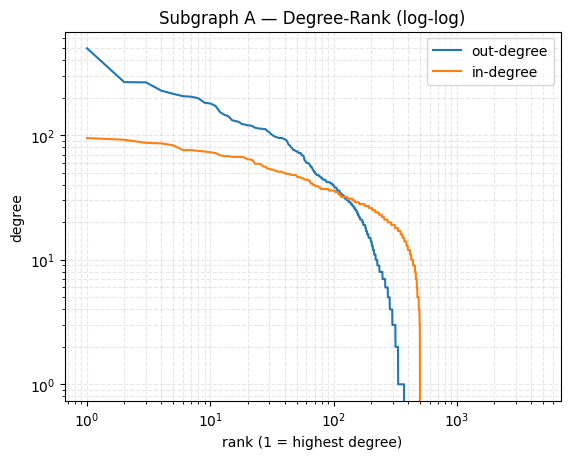

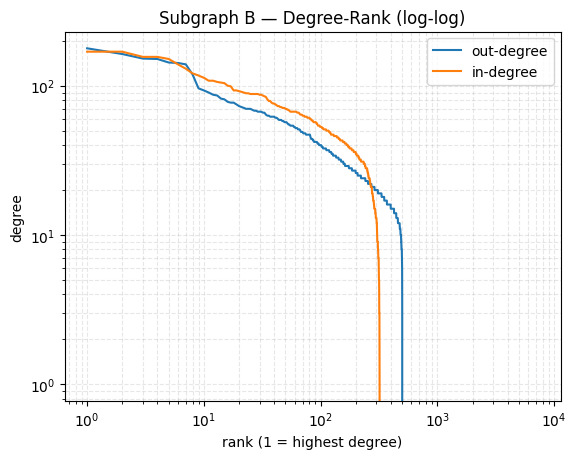

A_map rows: 500 mapped new_id count: 500
B_map rows: 500 mapped new_id count: 500


In [6]:
# ===== Cell 5 (FIXED): Load A/B, compute n correctly, normalize mappings, show stats =====
A_src, A_dst = read_edges_tsv(PATHS["A_edges"])
B_src, B_dst = read_edges_tsv(PATHS["B_edges"])

A_map_raw = read_mapping_tsv(PATHS["A_map"])
B_map_raw = read_mapping_tsv(PATHS["B_map"])

# n from edges (may miss isolated)
A_n_edges = n_from_reindexed_edges(A_src, A_dst)
B_n_edges = n_from_reindexed_edges(B_src, B_dst)

def max2_or0(df: pd.DataFrame) -> int:
    """max over col0/col1 safely; returns 0 if df empty."""
    if df is None or df.empty:
        return 0
    # no 'initial' in pandas; handle empty already above
    m0 = int(df["col0"].max())
    m1 = int(df["col1"].max())
    return max(m0, m1)

# n guess from mapping raw (covers all reindexed nodes, regardless of column order)
A_n_map = max2_or0(A_map_raw) + 1
B_n_map = max2_or0(B_map_raw) + 1

A_n = max(A_n_edges, A_n_map)
B_n = max(B_n_edges, B_n_map)

# normalize mapping to (old_id,new_id)
A_map = normalize_mapping(A_map_raw, A_n)
B_map = normalize_mapping(B_map_raw, B_n)

A_old_by_new = old_by_new(A_map, A_n)
B_old_by_new = old_by_new(B_map, B_n)

A_m = len(A_src); B_m = len(B_src)
A_loops = count_self_loops(A_src, A_dst)
B_loops = count_self_loops(B_src, B_dst)

A_in, A_out = in_out_degree_from_edges(A_n, A_src, A_dst)
B_in, B_out = in_out_degree_from_edges(B_n, B_src, B_dst)

print("A_n (edges, map_guess, final):", A_n_edges, A_n_map, A_n)
print("B_n (edges, map_guess, final):", B_n_edges, B_n_map, B_n)
print(f"Subgraph A: n={A_n}, m={A_m}, self_loops={A_loops}, deadends(out=0)={int((A_out==0).sum())}")
print(f"Subgraph B: n={B_n}, m={B_m}, self_loops={B_loops}, deadends(out=0)={int((B_out==0).sum())}")

display(degree_stats(A_in, A_out))
display(degree_stats(B_in, B_out))

plot_degree_rank(A_in, A_out, "Subgraph A")
plot_degree_rank(B_in, B_out, "Subgraph B")

# sanity: mapping should cover many new_ids
print("A_map rows:", len(A_map), "mapped new_id count:", int((A_old_by_new!=-1).sum()))
print("B_map rows:", len(B_map), "mapped new_id count:", int((B_old_by_new!=-1).sum()))

# Load FullGraph (robust)

FullGraph raw edges rows: 103689
FullGraph: n=7115, m=103689, self_loops=0, deadends(out=0)=1005


,deg_type,mean,median,max,zeros,zeros_%
0,out,14.573296,2.0,893,1005,14.125088
1,in,14.573296,0.0,457,4734,66.535488


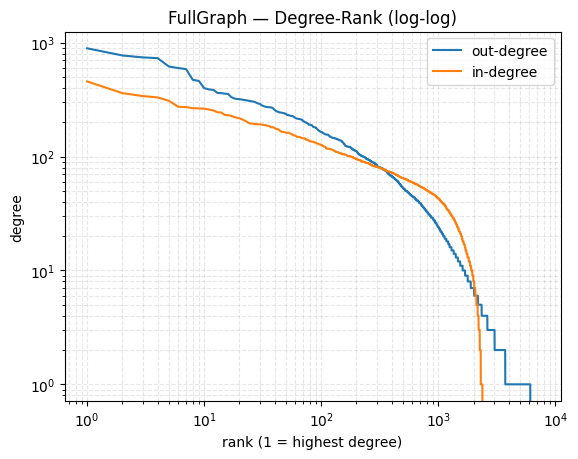

In [7]:
# ===== Cell 6: FullGraph load + reindex + stats =====
full_df = read_full_wikivote_gz(PATHS["FULL"])
print("FullGraph raw edges rows:", len(full_df))

full_nodes = pd.Index(pd.unique(pd.concat([full_df["src"], full_df["dst"]], ignore_index=True))).sort_values()
node_to_idx = pd.Series(np.arange(len(full_nodes), dtype=np.int64), index=full_nodes)
idx_to_node = full_nodes.to_numpy(dtype=np.int64)

full_src = node_to_idx.loc[full_df["src"]].to_numpy(dtype=np.int64, copy=False)
full_dst = node_to_idx.loc[full_df["dst"]].to_numpy(dtype=np.int64, copy=False)

FULL_n = len(full_nodes)
FULL_m = len(full_src)
FULL_loops = int(np.sum(full_src == full_dst))

FULL_in, FULL_out = in_out_degree_from_edges(FULL_n, full_src, full_dst)

print(f"FullGraph: n={FULL_n}, m={FULL_m}, self_loops={FULL_loops}, deadends(out=0)={int((FULL_out==0).sum())}")
display(degree_stats(FULL_in, FULL_out))

plot_degree_rank(FULL_in, FULL_out, "FullGraph")

# PageRank core (Dense/Sparse) + residual plot

In [8]:
# ===== Cell 7: Make row-stochastic + PageRank (unified dense/sparse walk) =====
def make_row_stochastic_dense(A: np.ndarray, out_deg: np.ndarray) -> np.ndarray:
    P = A.astype(np.float64, copy=True)
    n = P.shape[0]
    for i in range(n):
        d = int(out_deg[i])
        if d > 0:
            P[i, :] /= d
        else:
            P[i, :] = 0.0
    return P

def make_row_stochastic_csr(A: sparse.csr_matrix, out_deg: np.ndarray) -> sparse.csr_matrix:
    P = A.copy().tocsr().astype(np.float64)
    out_deg = np.asarray(out_deg, dtype=np.int64)
    for i in range(P.shape[0]):
        d = int(out_deg[i])
        if d > 0:
            s, e = P.indptr[i], P.indptr[i+1]
            if s != e:
                P.data[s:e] /= d
    return P

def l1_residual(p_new: np.ndarray, p_old: np.ndarray) -> float:
    return float(np.abs(p_new - p_old).sum())

def pagerank_power_iteration(
    P,
    r: float = 0.15,
    eps: float = 1e-9,
    max_iters: int = 500,
    q: np.ndarray | None = None,
    deadend_fix: str = "none",  # "none" | "fix-q" | "fix-u"
) -> dict:
    """
    Unified convention for BOTH dense and sparse:
        p_{t+1} = (1-r) * (P^T p_t) + r * q
    where P is row-stochastic (dangling rows are zeros).
    """
    n = int(P.shape[0])
    if q is None:
        q = np.full(n, 1.0/n, dtype=np.float64)
    else:
        q = np.asarray(q, dtype=np.float64)
        s = float(q.sum())
        if s <= 0:
            raise ValueError("q must have positive sum")
        q = q / s

    p = np.full(n, 1.0/n, dtype=np.float64)
    residuals = []
    uniform = np.full(n, 1.0/n, dtype=np.float64)

    for it in range(1, max_iters + 1):
        if sparse.isspmatrix(P):
            walk = P.T.dot(p)
        else:
            walk = (P.T @ p)
        walk = np.asarray(walk).reshape(-1)

        p_new = (1.0 - r) * walk + r * q

        if deadend_fix != "none":
            leaked = 1.0 - float(p_new.sum())
            if leaked != 0.0:
                if deadend_fix == "fix-q":
                    p_new = p_new + leaked * q
                elif deadend_fix == "fix-u":
                    p_new = p_new + leaked * uniform
                else:
                    raise ValueError(f"Unknown deadend_fix={deadend_fix}")

        res = l1_residual(p_new, p)
        residuals.append(res)
        p = p_new

        if res < eps:
            break

    return {
        "p": p,
        "iters": it,
        "residuals": np.array(residuals, dtype=np.float64),
        "residual_last": float(residuals[-1]) if residuals else None,
        "sum_p": float(p.sum()),
    }

def plot_residuals(residuals: np.ndarray, title: str):
    plt.figure()
    plt.semilogy(np.arange(1, len(residuals) + 1), residuals)
    plt.xlabel("iteration")
    plt.ylabel("L1 residual")
    plt.title(title + " — residual (log y)")
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.show()

def topk_pagerank(p: np.ndarray, k: int = 10) -> np.ndarray:
    idx = np.arange(len(p), dtype=np.int64)
    order = np.lexsort((idx, -p))
    return order[:k]

# Step 1: Dense PageRank on A & B


===== Dense PageRank: Subgraph A =====
deadends(out=0) = 4165
[Basic] iters=43 residual=9.150e-10 sum(p)=0.181419517584
[Fixed] iters=38 residual=8.289e-10 sum(p)=1.000000000000
Subgraph A Basic Top-10 new_id: [168  88 132 322 338 121 448 468 426 498]
Subgraph A Basic Top-10 old_id: [2625 2066 2398 3352 3456 2328 4191 4335 4037 4531]
Subgraph A Fixed Top-10 new_id: [168  88 132 322 338 121 448 468 426 498]
Subgraph A Fixed Top-10 old_id: [2625 2066 2398 3352 3456 2328 4191 4335 4037 4531]


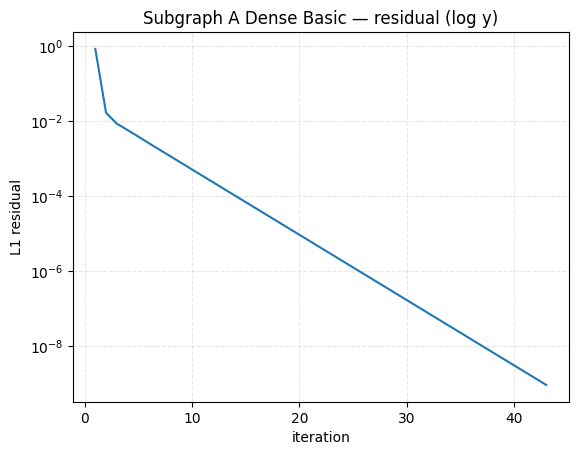

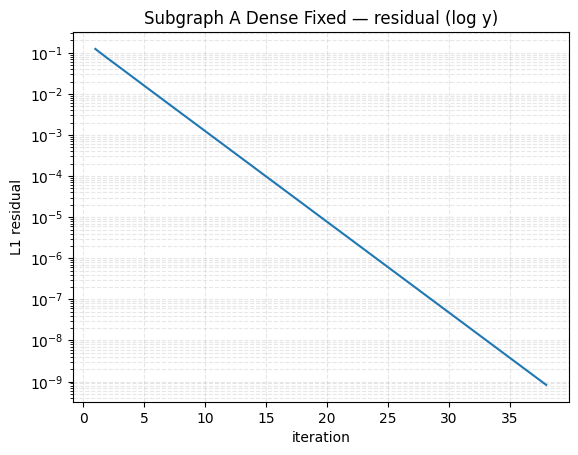


===== Dense PageRank: Subgraph B =====
deadends(out=0) = 6781
[Basic] iters=35 residual=7.657e-10 sum(p)=0.208371102870
[Fixed] iters=81 residual=8.603e-10 sum(p)=1.000000000000
Subgraph B Basic Top-10 new_id: [250 265 181 318 448 336 157 242 333  92]
Subgraph B Basic Top-10 old_id: [2398 2565 1549 3352 5800 3459 1297 2328 3456  737]
Subgraph B Fixed Top-10 new_id: [250 265 181 318 448 336 157 242 333  92]
Subgraph B Fixed Top-10 old_id: [2398 2565 1549 3352 5800 3459 1297 2328 3456  737]


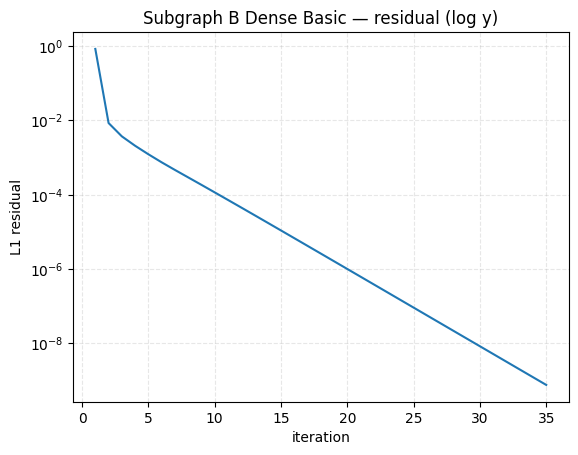

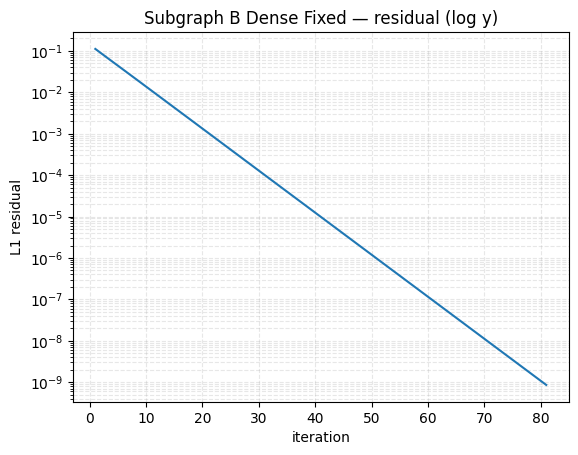

In [9]:
# ===== Cell 8: Dense PageRank on A/B + print top-10 in old_ids too =====
r = 0.15
eps = 1e-9
max_iters = 500

def print_topk_old_ids(name: str, p: np.ndarray, old_map: np.ndarray, k: int = 10):
    top_new = topk_pagerank(p, k)
    print(f"{name} Top-{k} new_id:", top_new)
    print(f"{name} Top-{k} old_id:", old_map[top_new])

def run_dense(name: str, n: int, src: np.ndarray, dst: np.ndarray, old_map: np.ndarray):
    print(f"\n===== Dense PageRank: {name} =====")
    A = build_dense_adjacency(n, src, dst)
    in_deg, out_deg = in_out_degree_from_edges(n, src, dst)
    P = make_row_stochastic_dense(A, out_deg)
    print("deadends(out=0) =", int((out_deg == 0).sum()))

    basic = pagerank_power_iteration(P, r=r, eps=eps, max_iters=max_iters, deadend_fix="none")
    fixed = pagerank_power_iteration(P, r=r, eps=eps, max_iters=max_iters, deadend_fix="fix-q")

    print(f"[Basic] iters={basic['iters']} residual={basic['residual_last']:.3e} sum(p)={basic['sum_p']:.12f}")
    print(f"[Fixed] iters={fixed['iters']} residual={fixed['residual_last']:.3e} sum(p)={fixed['sum_p']:.12f}")

    print_topk_old_ids(f"{name} Basic", basic["p"], old_map, k=10)
    print_topk_old_ids(f"{name} Fixed", fixed["p"], old_map, k=10)

    plot_residuals(basic["residuals"], f"{name} Dense Basic")
    plot_residuals(fixed["residuals"], f"{name} Dense Fixed")
    return {"basic": basic, "fixed": fixed}

dense_A = run_dense("Subgraph A", A_n, A_src, A_dst, A_old_by_new)
dense_B = run_dense("Subgraph B", B_n, B_src, B_dst, B_old_by_new)

# Mapping: print Top-10 as old_id

In [10]:
def old_by_new(mapping_df: pd.DataFrame, n: int) -> np.ndarray:
    arr = np.full(n, -1, dtype=np.int64)
    new_ids = mapping_df["new_id"].to_numpy(dtype=np.int64, copy=False)
    old_ids = mapping_df["old_id"].to_numpy(dtype=np.int64, copy=False)

    # Safety mask (should be all true if n was computed correctly)
    mask = (new_ids >= 0) & (new_ids < n)
    arr[new_ids[mask]] = old_ids[mask]
    return arr

A_old_by_new = old_by_new(A_map, A_n)
B_old_by_new = old_by_new(B_map, B_n)

def print_topk_old_ids(name: str, top_idx: np.ndarray, old_map: np.ndarray):
    print(f"{name} Top indices new_id:", top_idx)
    print(f"{name} Top node_ids old_id:", old_map[top_idx])

print("\nDense A Basic top10 (old ids):")
print_topk_old_ids("A", topk_pagerank(dense_A["basic"]["p"], 10), A_old_by_new)

print("\nDense A Fixed top10 (old ids):")
print_topk_old_ids("A", topk_pagerank(dense_A["fixed"]["p"], 10), A_old_by_new)

print("\nDense B Basic top10 (old ids):")
print_topk_old_ids("B", topk_pagerank(dense_B["basic"]["p"], 10), B_old_by_new)

print("\nDense B Fixed top10 (old ids):")
print_topk_old_ids("B", topk_pagerank(dense_B["fixed"]["p"], 10), B_old_by_new)


Dense A Basic top10 (old ids):
A Top indices new_id: [168  88 132 322 338 121 448 468 426 498]
A Top node_ids old_id: [2625 2066 2398 3352 3456 2328 4191 4335 4037 4531]

Dense A Fixed top10 (old ids):
A Top indices new_id: [168  88 132 322 338 121 448 468 426 498]
A Top node_ids old_id: [2625 2066 2398 3352 3456 2328 4191 4335 4037 4531]

Dense B Basic top10 (old ids):
B Top indices new_id: [250 265 181 318 448 336 157 242 333  92]
B Top node_ids old_id: [2398 2565 1549 3352 5800 3459 1297 2328 3456  737]

Dense B Fixed top10 (old ids):
B Top indices new_id: [250 265 181 318 448 336 157 242 333  92]
B Top node_ids old_id: [2398 2565 1549 3352 5800 3459 1297 2328 3456  737]


# Step 2: Sparse PageRank + timing

In [12]:
def run_sparse(graph_name: str, n: int, src: np.ndarray, dst: np.ndarray):
    t0 = time.perf_counter()
    A_csr = build_sparse_adjacency_csr(n, src, dst)
    t1 = time.perf_counter()

    in_deg, out_deg = in_out_degree_from_edges(n, src, dst)
    P_csr = make_row_stochastic_csr(A_csr, out_deg)
    t2 = time.perf_counter()

    pr = pagerank_power_iteration(P_csr, r=r, eps=eps, max_iters=max_iters, deadend_fix="none")
    t3 = time.perf_counter()

    return {
        "graph": graph_name,
        "n": int(n),
        "m_raw": int(len(src)),           # raw edge count (lines in edge list)
        "nnz": int(A_csr.nnz),            # unique edges (nonzeros in adjacency)
        "build_csr_s": float(t1 - t0),
        "normalize_s": float(t2 - t1),
        "iterate_s": float(t3 - t2),
        "total_s": float(t3 - t0),
        "iters": int(pr["iters"]),
        "sum_p": float(pr["sum_p"]),
        "P": P_csr,
        "out_deg": out_deg,
        "pr": pr,
    }

# --- Sparse for A/B (Basic only, for timing table) ---
sparse_A = run_sparse("A", A_n, A_src, A_dst)
sparse_B = run_sparse("B", B_n, B_src, B_dst)

timing_df = pd.DataFrame([{
    "graph": x["graph"],
    "n": x["n"],
    "m_raw": x["m_raw"],
    "nnz": x["nnz"],
    "build_csr_s": x["build_csr_s"],
    "normalize_s": x["normalize_s"],
    "iterate_s": x["iterate_s"],
    "total_s": x["total_s"],
    "iters": x["iters"],
    "sum_p": x["sum_p"],
} for x in [sparse_A, sparse_B]])

display(timing_df)

# --- FullGraph sparse: build once, then run none/fix-q/fix-u on same P ---
FULL_sparse_none = run_sparse("FullGraph", FULL_n, full_src, full_dst)
print(
    f"\nFullGraph sparse (none): n={FULL_sparse_none['n']} m_raw={FULL_sparse_none['m_raw']} nnz={FULL_sparse_none['nnz']} "
    f"iters={FULL_sparse_none['iters']} iterate_s={FULL_sparse_none['iterate_s']:.3f} sum(p)={FULL_sparse_none['sum_p']:.12f}"
)
print("avg iteration time:", FULL_sparse_none["iterate_s"] / FULL_sparse_none["iters"])

P_full = FULL_sparse_none["P"]

# fix-q timing
tq0 = time.perf_counter()
FULL_fix_q = pagerank_power_iteration(P_full, r=r, eps=eps, max_iters=max_iters, deadend_fix="fix-q")
tq1 = time.perf_counter()

# fix-u timing
tu0 = time.perf_counter()
FULL_fix_u = pagerank_power_iteration(P_full, r=r, eps=eps, max_iters=max_iters, deadend_fix="fix-u")
tu1 = time.perf_counter()

print(f"[Full fix-q] iters={FULL_fix_q['iters']} residual={FULL_fix_q['residual_last']:.3e} sum(p)={FULL_fix_q['sum_p']:.12f} iterate_s={tq1-tq0:.3f}")
print(f"[Full fix-u] iters={FULL_fix_u['iters']} residual={FULL_fix_u['residual_last']:.3e} sum(p)={FULL_fix_u['sum_p']:.12f} iterate_s={tu1-tu0:.3f}")

top20_q = topk_pagerank(FULL_fix_q["p"], 20)
top20_u = topk_pagerank(FULL_fix_u["p"], 20)

print("Top-20 node_ids (fix-q):", idx_to_node[top20_q])
print("Top-20 node_ids (fix-u):", idx_to_node[top20_u])

overlap = len(set(top20_q.tolist()) & set(top20_u.tolist()))
print("Top-20 overlap count:", overlap, "/ 20")

,graph,n,m_raw,nnz,build_csr_s,normalize_s,iterate_s,total_s,iters,sum_p
0,A,4537,12691,12691,0.000983,0.003301,0.008925,0.013209,43,0.181420
1,B,7281,14951,14951,0.000586,0.003543,0.005762,0.009891,35,0.208371



FullGraph sparse (none): n=7115 m_raw=103689 nnz=103689 iters=40 iterate_s=0.012 sum(p)=0.417565838176
avg iteration time: 0.0002924289250131551
[Full fix-q] iters=26 residual=7.199e-10 sum(p)=1.000000000000 iterate_s=0.008
[Full fix-u] iters=26 residual=7.199e-10 sum(p)=1.000000000000 iterate_s=0.008
Top-20 node_ids (fix-q): [4037   15 6634 2625 2398 2470 2237 4191 7553 5254 2328 1186 1297 4335 7620 5412 7632 4875 6946 3352]
Top-20 node_ids (fix-u): [4037   15 6634 2625 2398 2470 2237 4191 7553 5254 2328 1186 1297 4335 7620 5412 7632 4875 6946 3352]
Top-20 overlap count: 20 / 20


# Step 3: deadend fix

In [13]:


q_uniform = np.full(FULL_n, 1.0 / FULL_n, dtype=np.float64)

fixq = pagerank_power_iteration(P_full, r=r, eps=eps, max_iters=max_iters, q=q_uniform, deadend_fix="fix-q")
fixu = pagerank_power_iteration(P_full, r=r, eps=eps, max_iters=max_iters, q=q_uniform, deadend_fix="fix-u")

display(pd.DataFrame([
    {"method": "fix-q", "iters": fixq["iters"], "residual_last": fixq["residual_last"], "sum_p": fixq["sum_p"]},
    {"method": "fix-u", "iters": fixu["iters"], "residual_last": fixu["residual_last"], "sum_p": fixu["sum_p"]},
]))

top20_fixq = topk_pagerank(fixq["p"], 20)
top20_fixu = topk_pagerank(fixu["p"], 20)

print("\nTop-20 (fix-q) node_ids:", idx_to_node[top20_fixq])
print("Top-20 (fix-u) node_ids:", idx_to_node[top20_fixu])

overlap = len(set(top20_fixq.tolist()) & set(top20_fixu.tolist()))
print("\nTop-20 overlap size:", overlap)

,method,iters,residual_last,sum_p
0,fix-q,26,7.198700e-10,1.0
1,fix-u,26,7.198703e-10,1.0



Top-20 (fix-q) node_ids: [4037   15 6634 2625 2398 2470 2237 4191 7553 5254 2328 1186 1297 4335 7620 5412 7632 4875 6946 3352]
Top-20 (fix-u) node_ids: [4037   15 6634 2625 2398 2470 2237 4191 7553 5254 2328 1186 1297 4335 7620 5412 7632 4875 6946 3352]

Top-20 overlap size: 20


# Step 3B: Personalized PageRank (seed=4037)

In [14]:

seed_old_id = 4037
if seed_old_id not in node_to_idx.index:
    raise ValueError(f"Seed old_id={seed_old_id} not found in FullGraph node ids.")

seed_idx = int(node_to_idx.loc[seed_old_id])

q_seed = np.zeros(FULL_n, dtype=np.float64)
q_seed[seed_idx] = 1.0  # one-hot personalization

ppr = pagerank_power_iteration(P_full, r=r, eps=eps, max_iters=max_iters, q=q_seed, deadend_fix="fix-q")
print(f"PPR (seed={seed_old_id}): iters={ppr['iters']} residual={ppr['residual_last']:.3e} sum(p)={ppr['sum_p']:.12f}")

top20_ppr = topk_pagerank(ppr["p"], 20)

print("Top-20 PPR node_ids:", idx_to_node[top20_ppr])

display(pd.DataFrame({
    "rank": np.arange(1, 21, dtype=np.int64),
    "node_id": idx_to_node[top20_ppr],
    "ppr_score": ppr["p"][top20_ppr],
}))

PPR (seed=4037): iters=28 residual=6.781e-10 sum(p)=1.000000000000
Top-20 PPR node_ids: [4037   15 4256 7699 2958 8294  825 1385 3498 5693 4402 3717 6124 5226 4138 2014 3010 2237 2470 6634]


,rank,node_id,ppr_score
0,1,4037,0.338788
1,2,15,0.020404
2,3,4256,0.020062
3,4,7699,0.020011
4,5,2958,0.019876
5,6,8294,0.019753
6,7,825,0.019662
7,8,1385,0.019604
8,9,3498,0.019515
9,10,5693,0.019440


In [ ]:
top20_pr = topk_pagerank(fixq["p"], 20)  
top20_ppr = topk_pagerank(ppr["p"], 20)

overlap_pr_ppr = len(set(top20_pr.tolist()) & set(top20_ppr.tolist()))
print("Top-20 overlap (PR vs PPR):", overlap_pr_ppr, "/ 20")
print("Common node_ids:", np.intersect1d(idx_to_node[top20_pr], idx_to_node[top20_ppr]))

Top-20 overlap (PR vs PPR): 5 / 20
Common node_ids: [  15 2237 2470 4037 6634]
